Shape: (200, 200, 200)


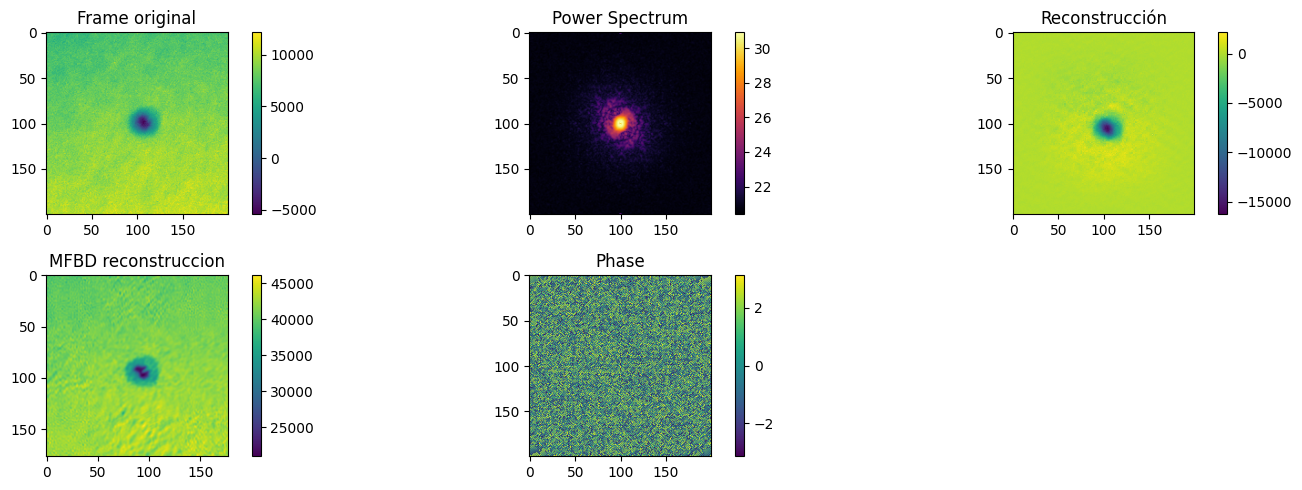

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from numpy.fft import fft2, ifft2, fftshift

USE_WINDOW = True
# ============================================================
# 1. CARGAR CUBO FITS
# ============================================================

filename = "continuum_200p_00197.fits"
MFBD = "continuum_200p_00197_MFBD.fits"

hdul = fits.open(filename)
data = hdul[0].data.astype(np.float32)

print("Shape:", data.shape)

# Suponemos:
# data.shape = (n_frames, height, width)

n_frames, H, W = data.shape

def create_hanning_window(shape):

    ny, nx = shape

    wy = np.hanning(ny)
    wx = np.hanning(nx)

    return np.outer(wy, wx)

if USE_WINDOW:
    window = create_hanning_window(data.shape[-2:])

# ============================================================
# 2. FFT DE TODOS LOS FRAMES
# ============================================================

fft_frames = []

for i in range(n_frames):

    frame = data[i]
    frame = frame.astype(np.float64)

    # opcional: quitar promedio
    frame = frame - np.mean(frame)

    if USE_WINDOW:
        frame = frame * window
        
    F = fft2(frame)

    fft_frames.append(F)

fft_frames = np.array(fft_frames)


# ============================================================
# 3. POWER SPECTRUM PROMEDIO
# ============================================================

power_spectrum = np.mean(np.abs(fft_frames) ** 2, axis=0)

# amplitud estimada
amplitude = np.sqrt(power_spectrum)



# ============================================================
# 7. RECONSTRUCCIÓN FINAL
# ============================================================

#----------
avg_fft = np.mean(fft_frames, axis=0)

phase_avg = np.angle(avg_fft)

reconstructed_fft = amplitude * np.exp(1j * phase_avg)

reconstructed_image = np.real(
    ifft2(reconstructed_fft)
)

reconstructed_image = np.real(ifft2(reconstructed_fft))
#---------

# ============================================================
# 8. VISUALIZACIÓN
# ============================================================

plt.figure(figsize=(15, 5))

plt.subplot(2, 3, 1)
plt.title("Frame original")
plt.imshow(data[0])
plt.colorbar()

plt.subplot(2, 3, 2)
plt.title("Power Spectrum")
plt.imshow(np.log1p(fftshift(power_spectrum)), cmap="inferno")
plt.colorbar()

plt.subplot(2, 3, 3)
plt.title("Reconstrucción")
plt.imshow(reconstructed_image)
plt.colorbar()

mfbd = fits.getdata(MFBD)
plt.subplot(2, 3, 4)
plt.title("MFBD reconstruccion")
plt.imshow(mfbd)
plt.colorbar()

plt.subplot(2, 3, 5)
plt.title("Phase")
plt.imshow(phase_avg)
plt.colorbar()

plt.tight_layout()
plt.show()

In [3]:
h, w = mfbd.shape

rh, rw = reconstructed_image.shape

y0 = (rh - h) // 2
x0 = (rw - w) // 2

recon_crop = reconstructed_image[
    y0:y0+h,
    x0:x0+w
]

from skimage.metrics import structural_similarity
from skimage.metrics import peak_signal_noise_ratio

def normalize(img):
    img = img.astype(np.float64)
    img -= img.min()
    img /= img.max()
    return img

mfbd_n = normalize(mfbd)
recon_n = normalize(recon_crop)

corr = np.corrcoef(
    mfbd_n.ravel(),
    recon_n.ravel()
)[0,1]

mse = np.mean(
    (mfbd_n - recon_n)**2
)

ssim = structural_similarity(
    mfbd_n,
    recon_n,
    data_range=1.0
)

psnr = peak_signal_noise_ratio(
    mfbd_n,
    recon_n,
    data_range=1.0
)

print("Correlation:", corr)
print("MSE:", mse)
print("SSIM:", ssim)
print("PSNR:", psnr)

Correlation: 0.8084777251113002
MSE: 0.006434594966828891
SSIM: 0.6701789270806979
PSNR: 21.91478785077748
